In [1]:
import sys
sys.path.append('..')

import tomodpdt

import numpy as np
import time
import matplotlib.pyplot as plt

import deeplay as dl

import torch
import torch.nn as nn
from torch.utils.data import DataLoader

In [2]:
DEV = 'cuda' if torch.cuda.is_available() else 'cpu'
print('Using device:', DEV)

Using device: cuda


In [3]:
data = np.load('D:/NewDataMonica/data_full_09_10_2024_HEK_03_04_us4.npz', allow_pickle=True)

In [4]:
data.keys()

KeysView(NpzFile 'D:/NewDataMonica/data_full_09_10_2024_HEK_03_04_us4.npz' with keys: E, q, t, n)

In [5]:
index_min = 0
index_max = 200

E = data['E'][index_min:index_max]
Q_GT = data['q'][index_min:index_max]
T_GT = data['t'][index_min:index_max]

In [6]:
E_upd = E.copy()

In [7]:
def correctfield(field, n_iter=5):
    """
    Correct field
    """

    if field.dtype == torch.float32:
        field = field.to(torch.complex64)

    f_new = field.clone()

    # Normalize with mean of absolute value.
    f_new = f_new / torch.mean(torch.abs(f_new))

    for _ in range(n_iter):
        f_new = f_new * torch.exp(-1j * torch.median(torch.angle(f_new)))

    return f_new

In [8]:
E = correctfield(torch.tensor(E_upd, device=DEV, dtype=torch.complex64), n_iter=5).cpu().numpy()

In [9]:
# Make 2 channels for imag and real part
E = np.stack([np.real(E), np.imag(E)], axis=1)

In [10]:
E.shape

(200, 2, 174, 200)

In [11]:
E.shape

(200, 2, 174, 200)

In [12]:
projections = torch.tensor(E, dtype=torch.float32).to(DEV)

In [13]:
nx, ny, nz = 174, 200, 150

In [14]:
from tomodpdt.imaging_modality_torch import setup_optics, imaging_model

# Setup the optics
optics_settings = setup_optics(
        shape=(nx, ny, nz),
        padding_xy=64, 
        microscopy_regime='Brightfield', 
        NA=1.15, 
        wavelength=640e-9, 
        resolution=200e-9, 
        magnification=1, 
        return_field=True)

# Generate the imaging model
brightfield_model = imaging_model(optics_setup=optics_settings)

In [15]:
Q_GT_new = np.zeros_like(Q_GT)
Q_GT_new[:, 0] = Q_GT[:, 0]
Q_GT_new[:, 1] = -Q_GT[:, 2]
Q_GT_new[:, 2] = -Q_GT[:, 3]
Q_GT_new[:, 3] = -Q_GT[:, 1]

dx = 200e-9
T_GT_new = np.zeros_like(T_GT)
T_GT_new[:, 0] = T_GT[:, 1] / dx
T_GT_new[:, 1] = T_GT[:, 2] / dx
T_GT_new[:, 2] = (T_GT[:, 0] - 150 * dx / 2) / dx


In [16]:
# Create the tomographic_model
tomographic_model = tomodpdt.Tomography(
    volume_size=(nx, ny, nz), # The size of the volume
    initial_volume='zeros', # 'refraction' since we are optimizing the refractive index
    rotation_optim_case='quaternion', # 'basis' or 'quaternion', 'basis' is smoother
    imaging_model=brightfield_model, # The imaging model,
    )

In [17]:
# Initialize the parameters
tomographic_model.initialize_parameters(projections, normalize=False, max_epochs=400)

c:\Users\Fredrik\miniconda3\envs\deeplaydev\Lib\site-packages\lightning\pytorch\trainer\connectors\logger_connector\logger_connector.py:76: Starting from v1.9.0, `tensorboardX` has been removed as a dependency of the `lightning.pytorch` package, due to potential conflicts with other packages in the ML ecosystem. For this reason, `logger=True` will use `CSVLogger` as the default logger, unless the `tensorboard` or `tensorboardX` packages are found. Please `pip install lightning[extra]` or one of them to enable TensorBoard support by default
c:\Users\Fredrik\miniconda3\envs\deeplaydev\Lib\site-packages\lightning\pytorch\trainer\configuration_validator.py:70: You defined a `validation_step` but have no `val_dataloader`. Skipping val loop.

  | Name                | Type                 | Params | Mode 
---------------------------------------------------------------------
0 | encoder             | Sequential           | 80.1 K | train
1 | fc_mu               | MultiLayerPerceptron | 281 K 

Epoch 399: 100%|██████████| 7/7 [00:00<00:00, 16.67it/s, v_num=1366, train_rec_loss_step=0.0732, train_KL_step=95.00, train_total_loss_step=0.0741, train_rec_loss_epoch=0.0733, train_KL_epoch=309.0, train_total_loss_epoch=0.0764]  


For vizualisation we initialize a `TomoPlotter` class.

In [18]:
plotter = tomodpdt.plotting.TomoPlotter(tomographic_model)


Using the VAE, we can visualize the **latent space** over time, revealing a trajectory that captures the system’s dynamics. Notably, **rotational movements** appear as transitions in this space, showing how the model encodes changes in orientation.


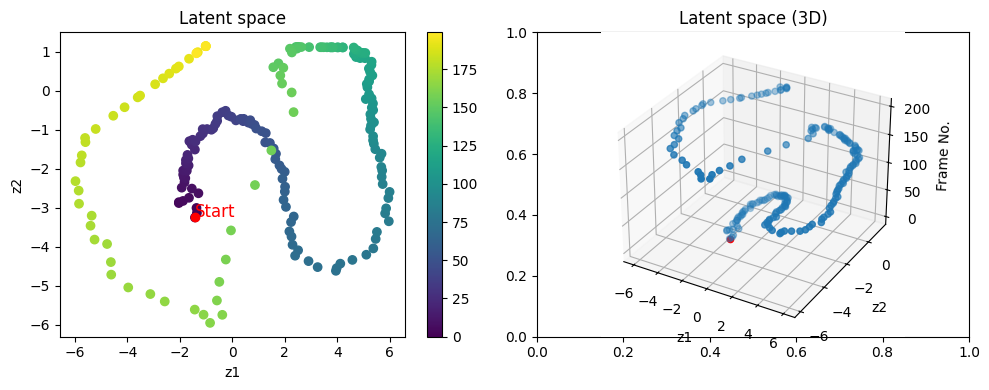

In [19]:
plotter.plot_latent_space()

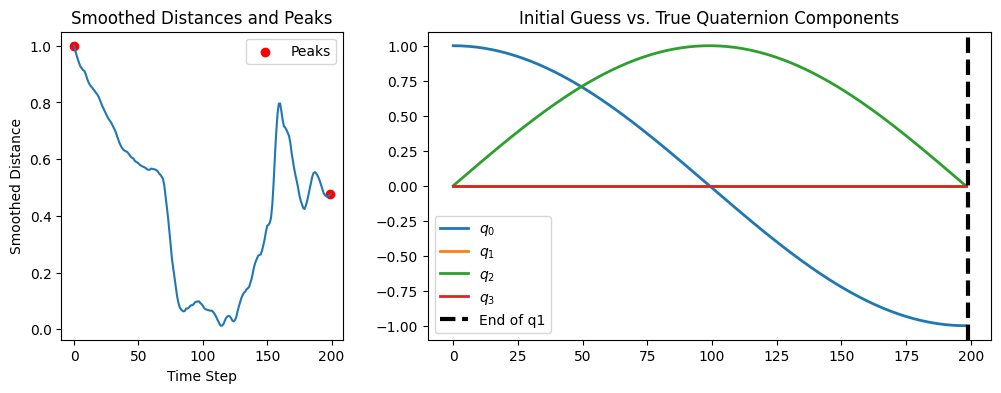

In [20]:
plotter.plot_smooth_dist_intial_guess()

To further validate the VAE, we compare reconstructed frames to the originals and observe a strong visual similarity.

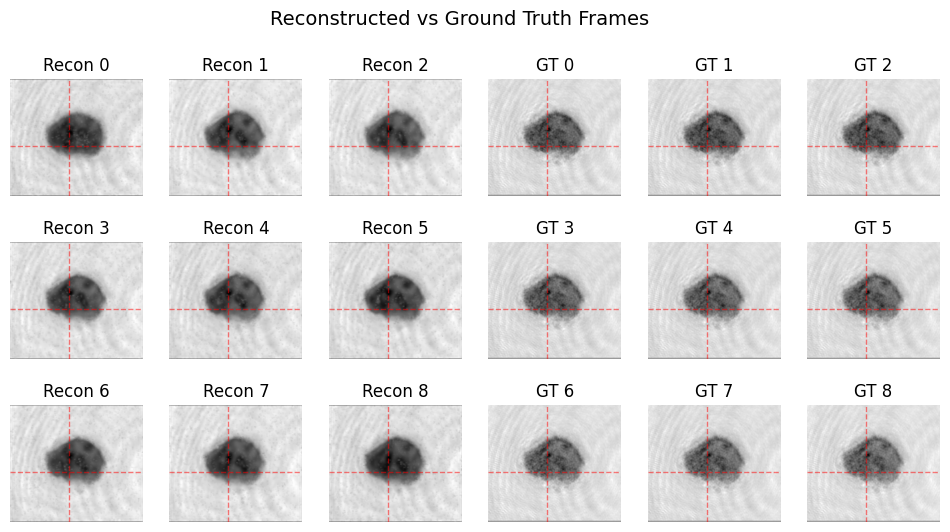

In [21]:
plotter.plot_reconstructed_vs_gt()

In [22]:
tomographic_model.rotation_params = torch.nn.Parameter(torch.tensor(Q_GT_new[:len(tomographic_model.rotation_params)]))
tomographic_model.translation_params = torch.nn.Parameter(torch.tensor(T_GT_new[:len(tomographic_model.translation_params)]))

# 
#tomographic_model.volume = torch.nn.Parameter(torch.tensor(volume).to(DEV))

In [23]:
#np.save('test_optics/volume_init4.npy', tomographic_model.volume.cpu().detach().numpy())

#volume = np.load('test_optics/volume_init4.npy')
#tomographic_model.volume = torch.nn.Parameter(torch.tensor(volume).to(DEV, dtype=torch.float32))
#tomographic_model.volume.requires_grad = True

### 3.3 - Optimize the volume alone first

As outline in the main section, it is now time to proceede with the actual 3D-reconstruction optimization.

The optimization process flows more effectively when an initial 3D volume is optimized first. To achieve this, the volume is optimized for a few iterations before both the volume and rotation parameters are jointly optimized. While it is possible to provide a custom initial volume to begin the optimization, in this case, we start with a fixed volume value of 1.33.

In [24]:
N1 = len(tomographic_model.frames) # Number of frames
idx = torch.arange(N1) # Index of frames
epochs_object_only = 500 # Number of epochs for the object only optimization
rotation_only = 5
batch_size_object_only = 8 # Batch size for the object only optimization

train the model for `epochs_object_only` epochs...

In [25]:
#tomographic_model.volume = nn.Parameter(torch.tensor(volume, dtype=torch.float32).to(DEV)-1.33)

In [26]:
# Move the model to device
tomographic_model.move_all_to_device(DEV)

tomographic_model.toggle_gradients_quaternion(False)
tomographic_model.toggle_gradients_translation(False)

# Number of iterations for the training loop
it = epochs_object_only 

trainer = dl.Trainer(max_epochs=it, accelerator="auto", enable_model_summary=False)

start_time = time.time()
trainer.fit(tomographic_model, DataLoader(idx, batch_size=batch_size_object_only, shuffle=True))
print("Training time: ", (time.time() - start_time) / 60, " minutes")

# Train the model
for i in range(it):
    pass
    #print(f"Iteration {i+1} of {it}")

    # First stage: optimize the volume only
    #trainer = dl.Trainer(max_epochs=epochs_object_only, accelerator="auto", enable_model_summary=False)

    # Toggle gradients for the volume
    #tomographic_model.toggle_gradients_quaternion(False)
    #tomographic_model.toggle_gradients_translation(False)
    #tomographic_model.toggle_gradients_volume(True)

    #start_time = time.time()
    #trainer.fit(tomographic_model, DataLoader(idx, batch_size=batch_size_object_only, shuffle=True))
    #print("Training time: ", (time.time() - start_time) / 60, " minutes")

    if False:
        # Second stage: optimize the translation and quaternion parameters
        trainer2 = dl.Trainer(max_epochs=rotation_only, accelerator="auto", enable_model_summary=False)

        tomographic_model.toggle_gradients_quaternion(True)
        tomographic_model.toggle_gradients_translation(True)
        tomographic_model.toggle_gradients_volume(False)

        start_time = time.time()
        idx_capping = np.random.randint(0, N1//6)  # Randomly cap the indices to avoid overfitting
        if np.random.rand() < 0.5: idx_capping = 0 # To disable capping

        trainer2.fit(tomographic_model, DataLoader(idx[idx_capping:-idx_capping], batch_size=N1//6, shuffle=False))
        print("Training time: ", (time.time() - start_time) / 60, " minutes") 


c:\Users\Fredrik\miniconda3\envs\deeplaydev\Lib\site-packages\lightning\pytorch\loops\fit_loop.py:310: The number of training batches (25) is smaller than the logging interval Trainer(log_every_n_steps=50). Set a lower value for log_every_n_steps if you want to see logs for the training epoch.


Epoch 2:  84%|████████▍ | 21/25 [00:28<00:05,  0.72it/s, v_num=1367, train_total_loss_step=4.030, train_proj_loss_step=3.120, train_ssim_loss_step=0.119, train_latent_loss_step=0.784, train_rtv_loss_step=0.000209, train_so_loss_step=0.00165, train_total_loss_epoch=4.300, train_proj_loss_epoch=3.430, train_ssim_loss_epoch=0.125, train_latent_loss_epoch=0.740, train_rtv_loss_epoch=0.000186, train_so_loss_epoch=0.00128]

NameError: name 'exit' is not defined

(<Figure size 1500x1000 with 6 Axes>,
 array([[<Axes: title={'center': 'Total loss'}, xlabel='Step'>,
         <Axes: title={'center': 'Proj loss'}, xlabel='Step'>,
         <Axes: title={'center': 'Ssim loss'}, xlabel='Step'>],
        [<Axes: title={'center': 'Latent loss'}, xlabel='Step'>,
         <Axes: title={'center': 'Rtv loss'}, xlabel='Step'>, <Axes: >]],
       dtype=object))

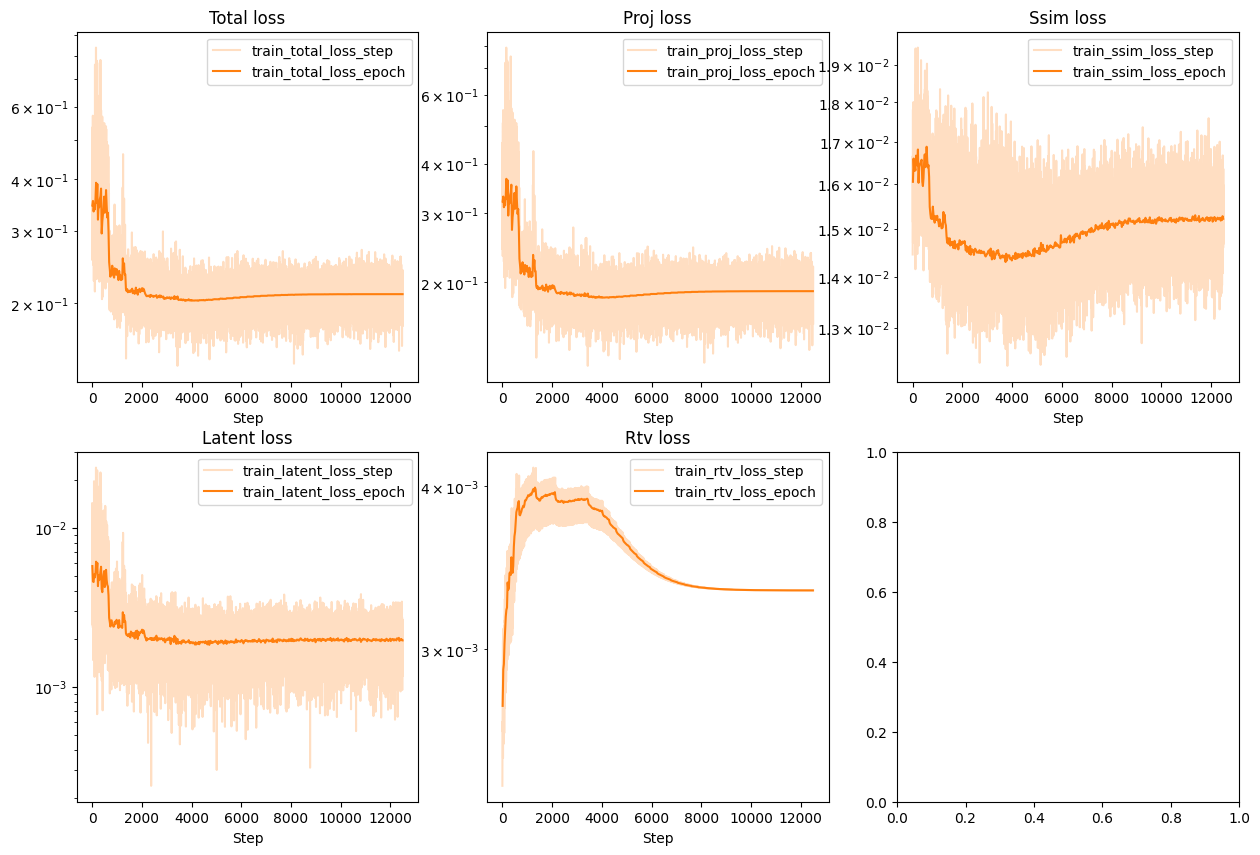

In [ ]:
trainer.history.plot()

## 4.0 - Visualize the reconstructed volume and the parameters

Finally, we visualize the reconstructed 3D volume and the rotation parameters. The reconstructed volume is displayed as a 3D volume, while the rotation parameters are represented in a 3D scatter plot.

In [ ]:
# Clear the GPU memory
torch.cuda.empty_cache()

In [ ]:
# Move it to the GPU if possible for faster plotting
tomographic_model.move_all_to_device(DEV)

# Visualize the final volume and rotations.
plotter = tomodpdt.plotting.TomoPlotter(tomographic_model)

By visualizing summation views of the 3D object along the x, y, and z axes, we can assess how well the optimized volume matches the ground truth.

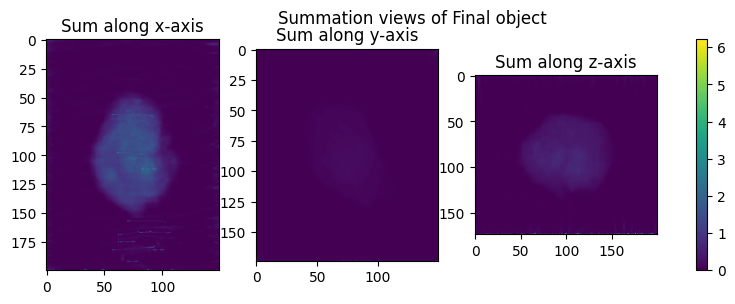

In [ ]:
plotter.plot_sum_object(save_name="Final object")

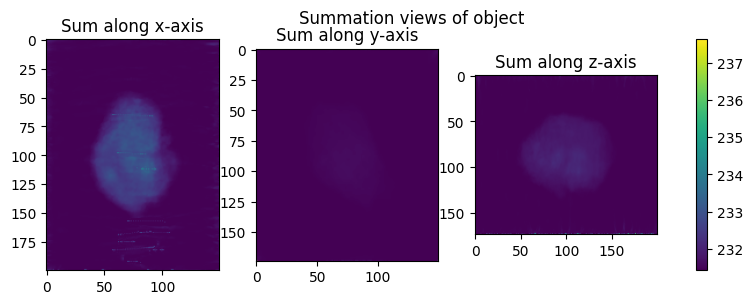

In [ ]:
vol = tomographic_model.volume.cpu().detach().numpy()
tomodpdt.plotting.plot_sum_object(vol+1.33)


In [ ]:
test = torch.zeros_like(tomographic_model.volume) + 1e-3

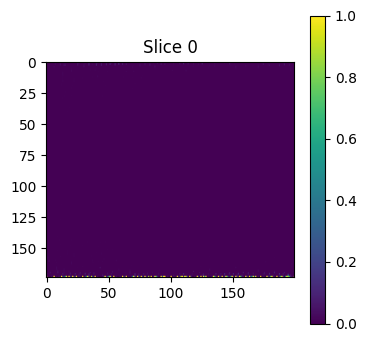

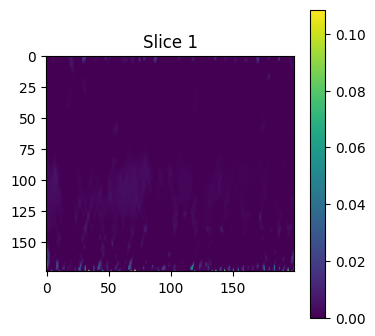

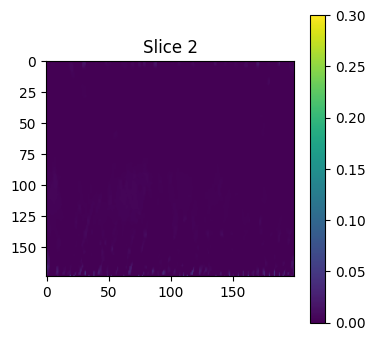

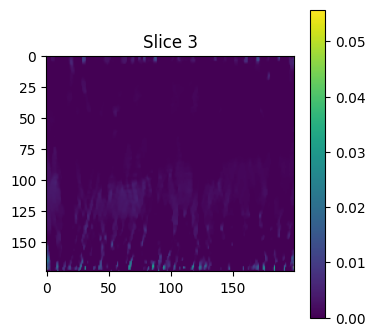

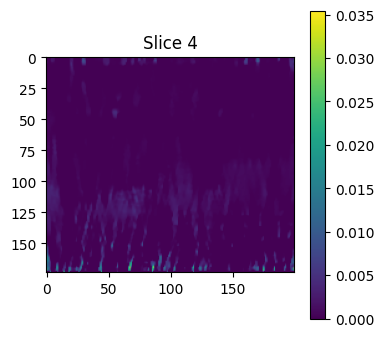

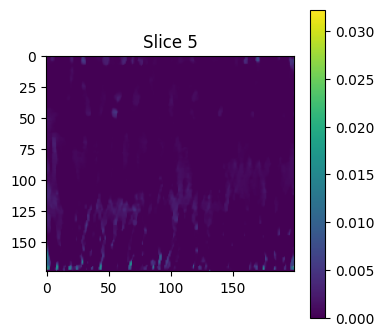

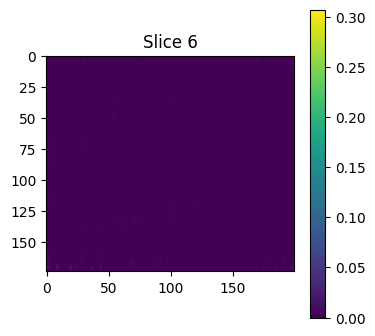

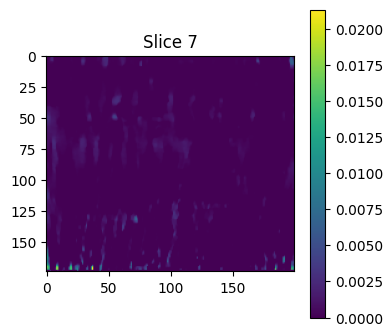

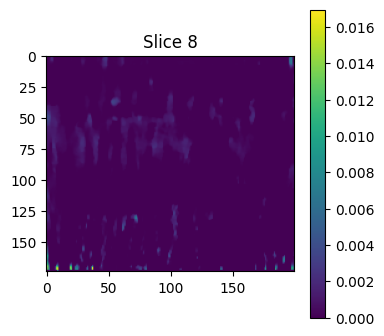

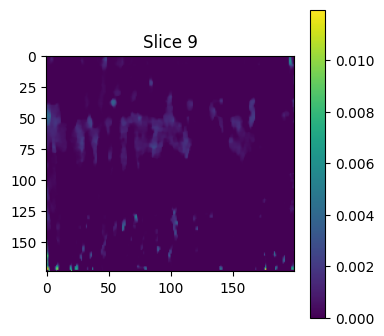

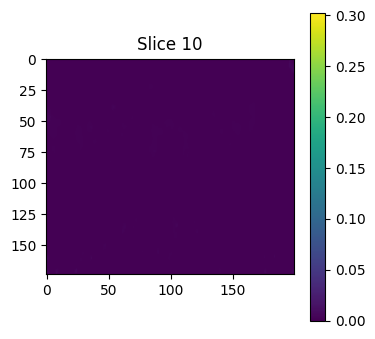

In [ ]:
count=0
for i in range(0, vol.shape[0]):
    if np.max(vol[:, :, i]) < 0.005:
        continue
    else:
        count += 1
    plt.figure(figsize=(4, 4))
    plt.imshow(vol[:, :, i])
    plt.colorbar()
    plt.title(f'Slice {i}')
    plt.show()

    if count > 10:
        break


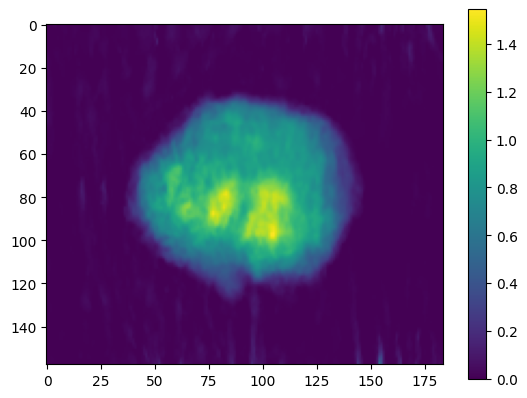

In [ ]:
crop = 8
plt.imshow(tomographic_model.volume[crop:-crop, crop:-crop, crop:-crop].detach().cpu().sum(2))
plt.colorbar()

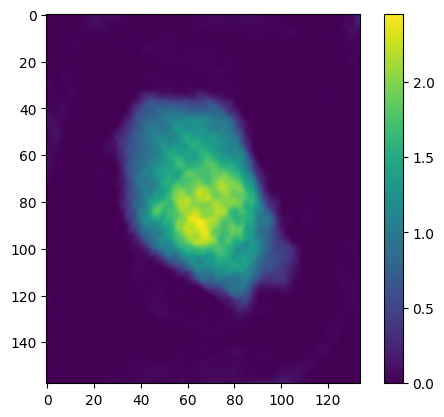

In [ ]:
crop = 8
plt.imshow(tomographic_model.volume[crop:-crop, crop:-crop, crop:-crop].detach().cpu().sum(1))
plt.colorbar()

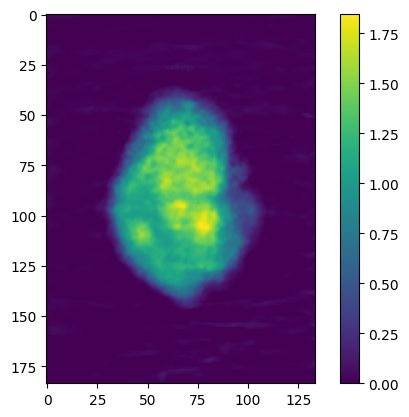

In [ ]:
crop = 8
plt.imshow(tomographic_model.volume[crop:-crop, crop:-crop, crop:-crop].detach().cpu().sum(0))
plt.colorbar()

In [ ]:
dRI = tomographic_model.volume[crop:-crop, crop:-crop, crop:-crop]

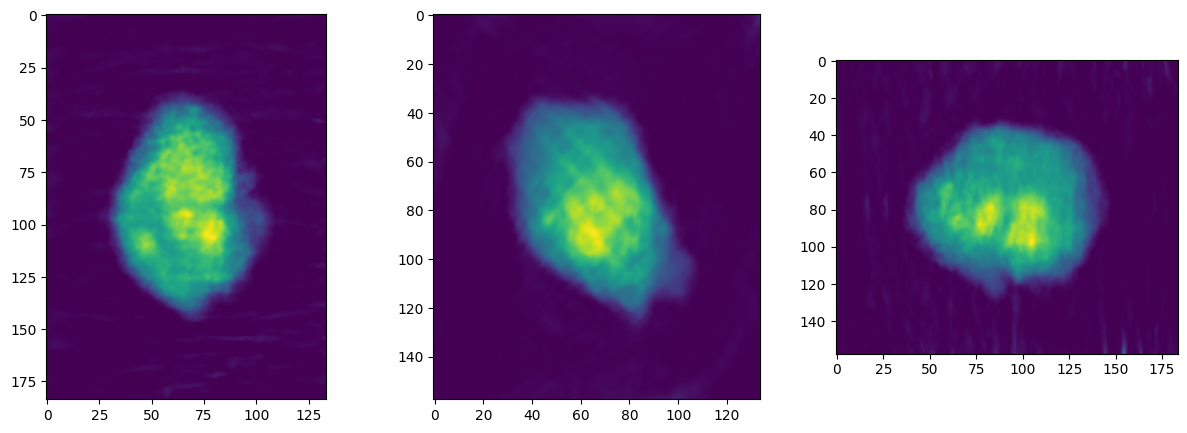

In [ ]:
plt.figure(figsize=(15, 5))
plt.subplot(131)
plt.imshow(dRI.cpu().detach().numpy().sum(axis=0))

plt.subplot(132)
plt.imshow(dRI.cpu().detach().numpy().sum(axis=1))

plt.subplot(133)
plt.imshow(dRI.cpu().detach().numpy().sum(axis=2))

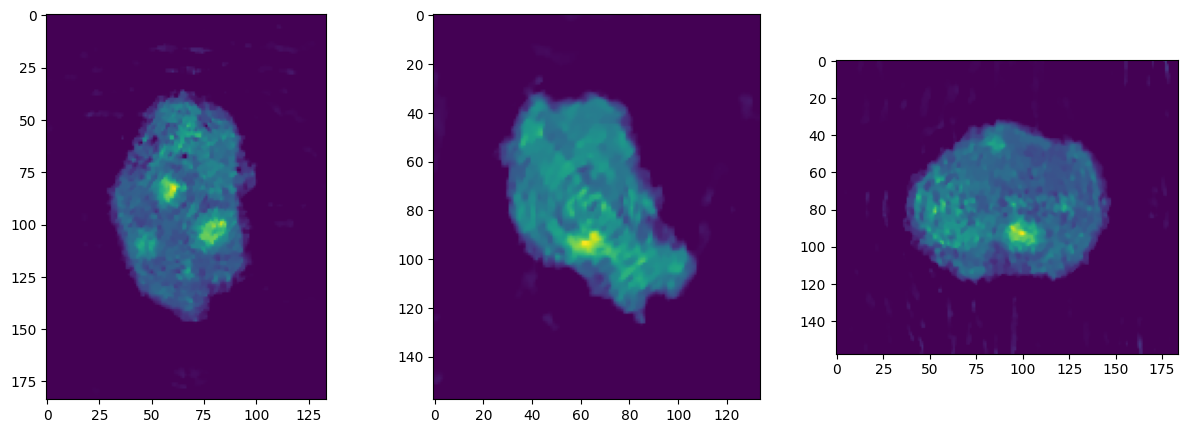

In [ ]:
xs, ys, zs = dRI.shape

plt.figure(figsize=(15, 5))
plt.subplot(131)
plt.imshow(dRI.cpu().detach().numpy()[xs//2])

plt.subplot(132)
plt.imshow(dRI.cpu().detach().numpy()[:, ys//2])

plt.subplot(133)
plt.imshow(dRI.cpu().detach().numpy()[:, :, zs//2])

Instead of summation views, we can visualize the forward projections of the reconstructed object and compare them to the ground truth 2D frames. The similarity indicates a successful reconstruction.

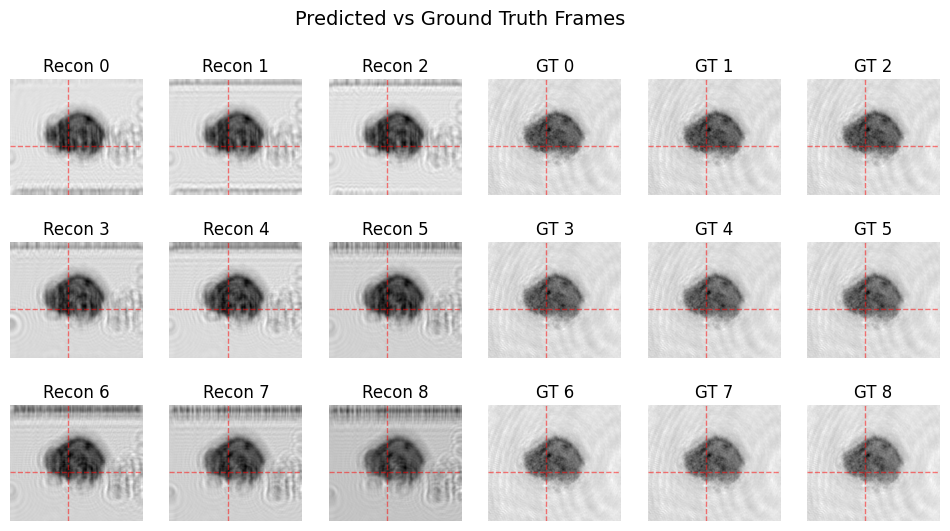

In [ ]:
plotter.plot_reconstructed_vs_gt(column_headers=["Predicted", "Ground Truth"], forward=True, save_name="Reconstructed vs GT")

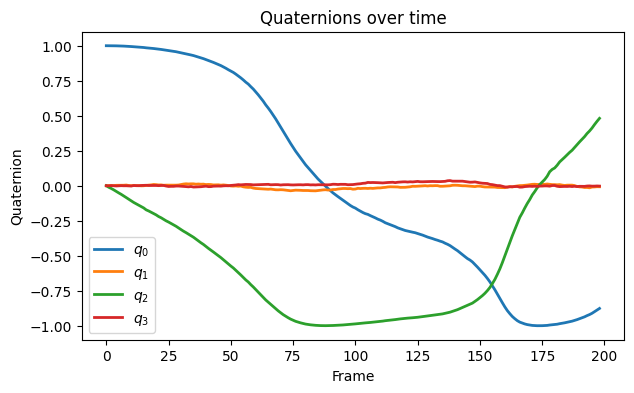

In [ ]:
plotter.plot_quaternions()

In [ ]:
idx = np.random.randint(0, len(tomographic_model.rotation_params), 10)

In [ ]:
forward_projections = tomographic_model.full_forward_final(max_projections=10, idx=idx)

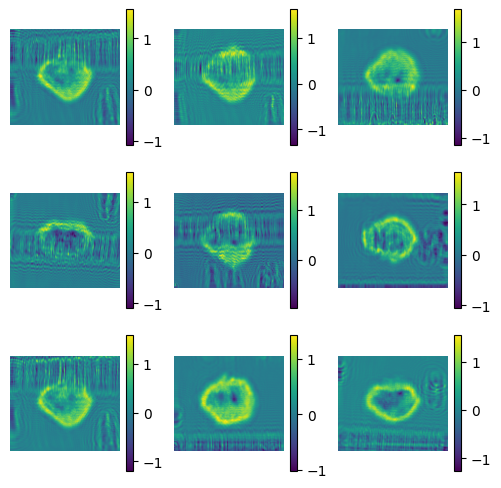

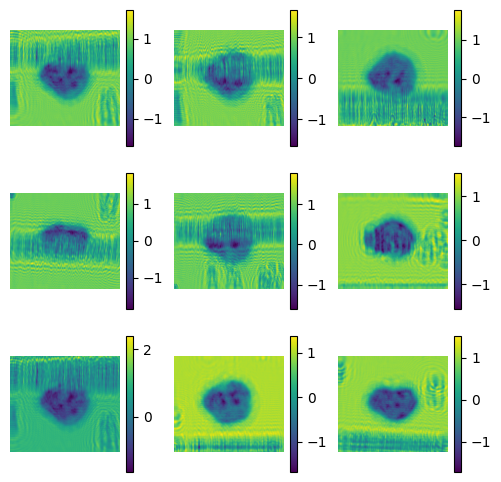

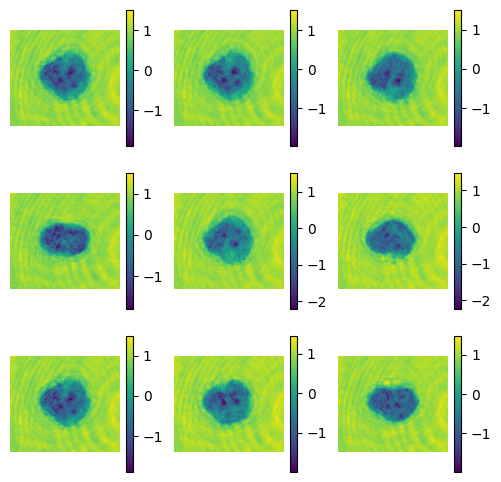

In [ ]:
plt.figure(figsize=(6, 6))
for i in range(9):
    #Set values below th to zero
    proj_upd = forward_projections[i, 1].detach().cpu().numpy()

    #proj_upd[proj_upd < th] = 0

    plt.subplot(3, 3, i + 1)
    plt.imshow(proj_upd)
    plt.colorbar()
    plt.axis('off')
plt.show()

plt.figure(figsize=(6, 6))
for i in range(9):
    #Set values below th to zero
    proj_upd = forward_projections[i, 0].detach().cpu().numpy()

    #proj_upd[proj_upd < th] = 0

    plt.subplot(3, 3, i + 1)
    plt.imshow(proj_upd)
    plt.colorbar()
    plt.axis('off')
plt.show()

# show projections
plt.figure(figsize=(6, 6))
for i, idx_ in enumerate(idx):
    if i >= 9:
        break
    proj_upd = tomographic_model.frames[idx_].detach().cpu().numpy()
    plt.subplot(3, 3, i + 1)
    plt.imshow(proj_upd[0])
    plt.colorbar()
    plt.axis('off')
plt.show()

Text(0.5, 0, 'Frame index')

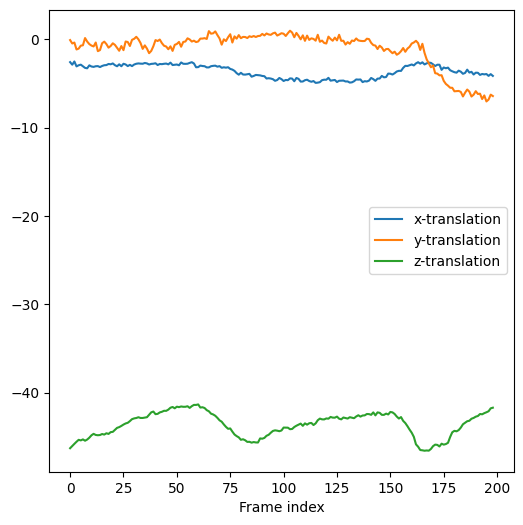

In [ ]:
tt =  tomographic_model.get_translations_final()

plt.figure(figsize=(6, 6))
plt.plot(tt[:, 0].detach().cpu().numpy(), label='x-translation')
plt.plot(tt[:, 1].detach().cpu().numpy(), label='y-translation')
plt.plot(tt[:, 2].detach().cpu().numpy(), label='z-translation')
plt.legend()
plt.xlabel('Frame index')